In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.io import arff

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.calibration import CalibratedClassifierCV, calibration_curve

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve
)

from imblearn.over_sampling import SMOTE

import shap
import warnings
warnings.filterwarnings("ignore")

In [31]:

print("Loading ARFF dataset...")

data = arff.loadarff("1year.arff")

df = pd.DataFrame(data[0])

# convert byte column to int
df["class"] = df["class"].astype(int)

print("Dataset shape:", df.shape)

TARGET = "class"

Loading ARFF dataset...
Dataset shape: (7027, 65)


In [32]:
X = df.drop(TARGET, axis=1)
y = df[TARGET]

# handle missing values
imputer = SimpleImputer(strategy="median")
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

# scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# train test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (5270, 64)
Test size: (1757, 64)


In [33]:
smote = SMOTE(random_state=42)

X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print("Balanced training size:", X_train_bal.shape)

Balanced training size: (10134, 64)


In [34]:
print("\nTraining Logistic Regression...")

log_model = LogisticRegression(max_iter=2000)

log_model.fit(X_train_bal, y_train_bal)

log_probs = log_model.predict_proba(X_test)[:,1]
log_preds = log_model.predict(X_test)


Training Logistic Regression...


In [21]:

print("\nTraining Random Forest...")

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf_model.fit(X_train_bal, y_train_bal)

rf_probs = rf_model.predict_proba(X_test)[:,1]
rf_preds = rf_model.predict(X_test)


Training Random Forest...


In [22]:
print("\nCalibrating probabilities...")

calibrator = CalibratedClassifierCV(
    rf_model,
    method="isotonic",
    cv=3
)

calibrator.fit(X_train_bal, y_train_bal)

cal_probs = calibrator.predict_proba(X_test)[:,1]


Calibrating probabilities...


In [23]:

def evaluate_model(name, y_true, y_pred, y_prob):

    print("\n", name)
    print("-"*30)

    print("Accuracy :", round(accuracy_score(y_true,y_pred),3))
    print("Precision:", round(precision_score(y_true,y_pred),3))
    print("Recall   :", round(recall_score(y_true,y_pred),3))
    print("ROC AUC  :", round(roc_auc_score(y_true,y_prob),3))


evaluate_model("Logistic Regression", y_test, log_preds, log_probs)
evaluate_model("Random Forest", y_test, rf_preds, rf_probs)


 Logistic Regression
------------------------------
Accuracy : 0.653
Precision: 0.067
Recall   : 0.618
ROC AUC  : 0.673

 Random Forest
------------------------------
Accuracy : 0.937
Precision: 0.31
Recall   : 0.515
ROC AUC  : 0.91


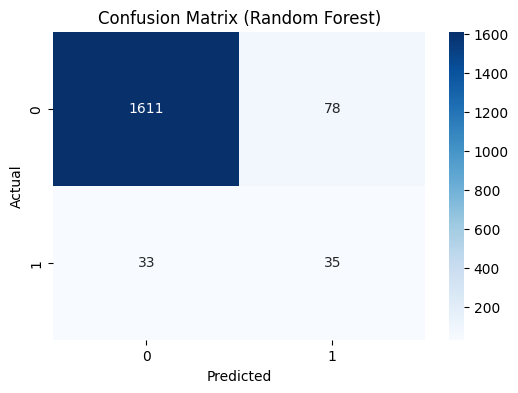

In [24]:
cm = confusion_matrix(y_test, rf_preds)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix (Random Forest)")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

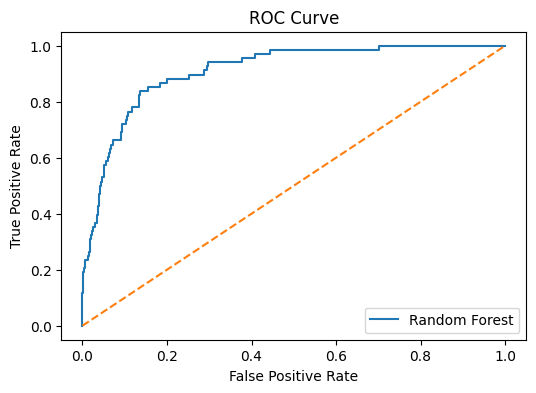

In [25]:
fpr, tpr, _ = roc_curve(y_test, rf_probs)

plt.figure(figsize=(6,4))

plt.plot(fpr, tpr, label="Random Forest")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()

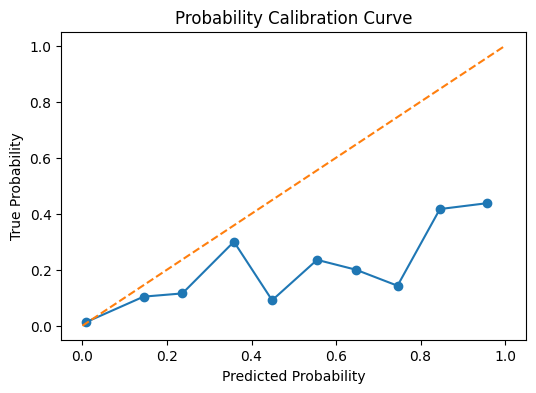

In [26]:
prob_true, prob_pred = calibration_curve(y_test, cal_probs, n_bins=10)

plt.figure(figsize=(6,4))

plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1],[0,1],'--')

plt.title("Probability Calibration Curve")
plt.xlabel("Predicted Probability")
plt.ylabel("True Probability")

plt.show()

In [27]:
risk_df = pd.DataFrame({
    "Probability_of_Bankruptcy": cal_probs
})

def assign_risk(p):

    if p < 0.2:
        return "Low Risk"

    elif p < 0.5:
        return "Moderate Risk"

    elif p < 0.75:
        return "High Risk"

    else:
        return "Severe Risk"


risk_df["Risk_Category"] = risk_df[
    "Probability_of_Bankruptcy"
].apply(assign_risk)

print(risk_df.head())

   Probability_of_Bankruptcy  Risk_Category
0                   0.494236  Moderate Risk
1                   0.000000       Low Risk
2                   0.109678       Low Risk
3                   0.000000       Low Risk
4                   0.060283       Low Risk



Top Risk Drivers:
   Feature  Importance
26  Attr27    0.093556
23  Attr24    0.053717
45  Attr46    0.047153
5    Attr6    0.035584
12  Attr13    0.033390
33  Attr34    0.030725
25  Attr26    0.027980
28  Attr29    0.026961
15  Attr16    0.025241
4    Attr5    0.023665


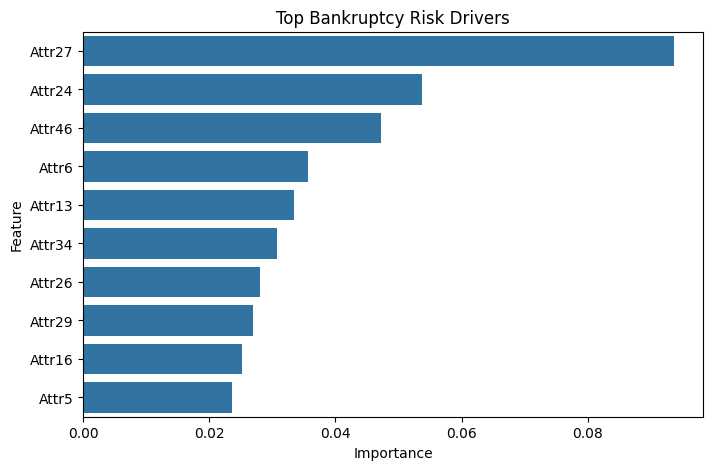

In [28]:
importances = rf_model.feature_importances_

feat_imp = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
})

feat_imp = feat_imp.sort_values(
    by="Importance",
    ascending=False
)

print("\nTop Risk Drivers:")
print(feat_imp.head(10))


plt.figure(figsize=(8,5))

sns.barplot(
    x="Importance",
    y="Feature",
    data=feat_imp.head(10)
)

plt.title("Top Bankruptcy Risk Drivers")

plt.show()

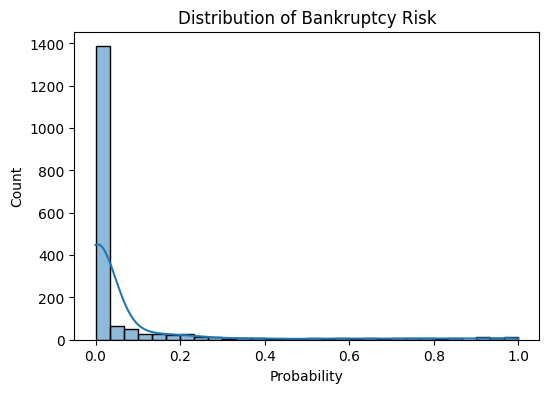


Pipeline complete.


In [29]:
plt.figure(figsize=(6,4))

sns.histplot(
    risk_df["Probability_of_Bankruptcy"],
    bins=30,
    kde=True
)

plt.title("Distribution of Bankruptcy Risk")
plt.xlabel("Probability")
plt.ylabel("Count")

plt.show()


print("\nPipeline complete.")